In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("kc_house_data.csv")

In [3]:
# Step 3: Make our 4 features + price
#   Rooms     = bedrooms
#   PlotArea  = sqft_lot
#   Location  = zipcode
#   Age       = 2015 - year built (this data is from 2014-2015)
data = pd.DataFrame()
data["Rooms"] = df["bedrooms"]
data["PlotArea"] = df["sqft_lot"]
data["Age"] = 2015 - df["yr_built"]
data["Location"] = df["zipcode"].astype(str)    # zipcode is a name, not a number
data["Price"] = df["price"]
data = data.dropna()
data = data[data["Rooms"] <= 10]                # remove unusual houses
print(data.head())

   Rooms  PlotArea  Age Location     Price
0      3      5650   60    98178  221900.0
1      3      7242   64    98125  538000.0
2      2     10000   82    98028  180000.0
3      4      5000   50    98136  604000.0
4      3      8080   28    98074  510000.0


In [4]:
data = pd.get_dummies(data, columns=["Location"], drop_first=True, dtype=int)

In [5]:
X = data.drop("Price", axis=1)
y = data["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
model1 = LinearRegression()
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)
print("Without scaling -> MSE:", mean_squared_error(y_test, pred1), " R2:", r2_score(y_test, pred1))

Without scaling -> MSE: 77304546101.59042  R2: 0.4650516380742743


In [7]:
num_cols = ["Rooms", "PlotArea", "Age"]     # only scale the number columns
X_train_std = X_train.copy()
X_test_std = X_test.copy()
std = StandardScaler()
X_train_std[num_cols] = std.fit_transform(X_train[num_cols])
X_test_std[num_cols] = std.transform(X_test[num_cols])

In [8]:
model2 = LinearRegression()
model2.fit(X_train_std, y_train)
pred2 = model2.predict(X_test_std)
print("Standardized    -> MSE:", mean_squared_error(y_test, pred2), " R2:", r2_score(y_test, pred2))

Standardized    -> MSE: 77304546101.59158  R2: 0.4650516380742662


In [9]:
# Step 8: Model WITH Normalization (values between 0 and 1)
X_train_mm = X_train.copy()
X_test_mm = X_test.copy()
mm = MinMaxScaler()
X_train_mm[num_cols] = mm.fit_transform(X_train[num_cols])
X_test_mm[num_cols] = mm.transform(X_test[num_cols])

In [10]:
model3 = LinearRegression()
model3.fit(X_train_mm, y_train)
pred3 = model3.predict(X_test_mm)
print("Normalized      -> MSE:", mean_squared_error(y_test, pred3), " R2:", r2_score(y_test, pred3))

Normalized      -> MSE: 77304546101.59155  R2: 0.4650516380742665


In [11]:
print(pd.DataFrame({
    "Feature": num_cols,
    "Normal coef": model1.coef_[:3],
    "Scaled coef": model2.coef_[:3]
}))

    Feature   Normal coef   Scaled coef
0     Rooms  95424.563556  86512.127320
1  PlotArea      1.202971  46665.379198
2       Age  -1255.125572 -36821.132432


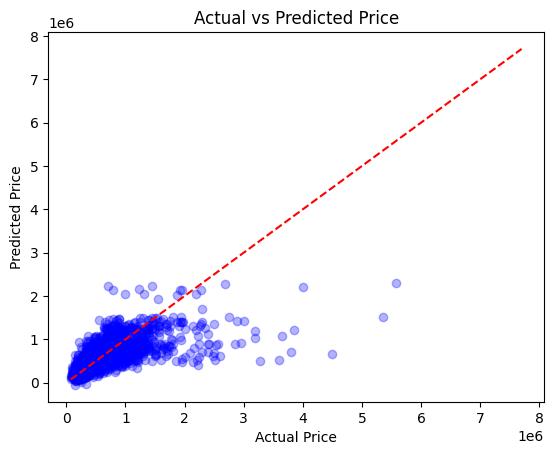

In [12]:
plt.scatter(y_test, pred2, color="blue", alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")   # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()